In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt



In [2]:
#time to check
slice_str = "2024-07-01T00:00:00, 2024-07-31T23:59:00"
slice_tuple = tuple(slice_str.split(", "))


In [3]:
data_era = xr.open_mfdataset(r'..\data\ERA5\profiles\*.nc')
time_dim = 'valid_time'
data_era_1min = data_era.resample({time_dim: '1min'}).interpolate('linear')


In [4]:
data_era = data_era_1min.sel(valid_time=slice(*slice_tuple))
data_era = data_era.sel(latitude=51.96,longitude=4.9,method='nearest')
data_era = data_era.sortby('pressure_level', ascending=False)
data_era = data_era.sel(pressure_level=slice(1e5,200))
time = data_era_1min.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

In [5]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


In [10]:
time_conv = rain_rate.time.values[rain_rate.values > 10]

In [11]:
time_conv

array(['2024-07-03T07:22:00', '2024-07-03T08:22:00',
       '2024-07-03T08:23:00', '2024-07-04T02:53:00',
       '2024-07-04T02:54:00', '2024-07-04T02:59:00',
       '2024-07-06T19:52:00', '2024-07-06T20:55:00',
       '2024-07-06T20:56:00', '2024-07-06T20:57:00',
       '2024-07-06T21:00:00', '2024-07-06T21:01:00',
       '2024-07-06T21:02:00', '2024-07-06T21:03:00',
       '2024-07-06T21:07:00', '2024-07-07T14:26:00',
       '2024-07-09T17:13:00', '2024-07-09T17:14:00',
       '2024-07-09T17:15:00', '2024-07-09T17:26:00',
       '2024-07-09T17:30:00', '2024-07-09T18:19:00',
       '2024-07-09T18:20:00', '2024-07-12T16:36:00',
       '2024-07-12T17:56:00', '2024-07-12T17:57:00',
       '2024-07-16T11:45:00', '2024-07-16T11:46:00',
       '2024-07-16T15:14:00', '2024-07-16T15:15:00',
       '2024-07-16T15:17:00', '2024-07-16T15:28:00',
       '2024-07-20T16:11:00', '2024-07-20T16:23:00',
       '2024-07-20T16:24:00', '2024-07-20T16:25:00',
       '2024-07-20T16:26:00', '2024-07-20T16:2

In [6]:
radar_cabauw = xr.open_mfdataset(
    r'..\data\Cabauw_radar\*.nc',
    data_vars=['Zh'],
    coords='minimal',      # resolves conflict
    compat='override',     # if you really need it
    combine='by_coords'
)

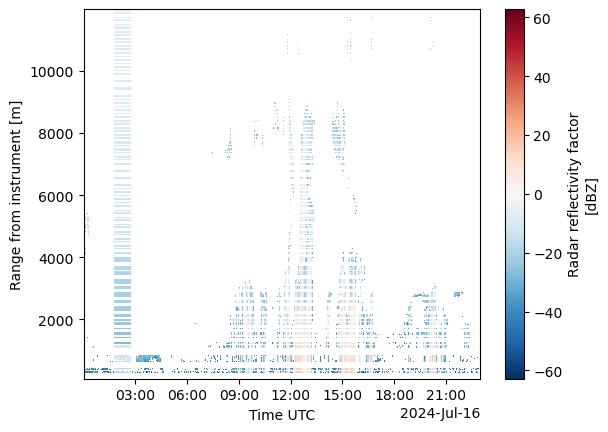

In [17]:
radar_cabauw.Zh.sel(time=slice("2024-07-16T00:00:00.598999980", "2024-07-16T23:00:03.774000098")).plot(x='time', y='range')


In [ ]:
radar_cabauw

<xarray.Dataset> Size: 25GB
Dimensions:                     (chirp_sequence: 3, time: 801697, range: 648)
Coordinates:
  * range                       (range) float32 3kB 102.2 119.2 ... 1.198e+04
  * time                        (time) datetime64[ns] 6MB 2024-07-01T00:00:00...
Dimensions without coordinates: chirp_sequence
Data variables: (12/55)
    file_code                   float64 8B ...
    program_number              float64 8B ...
    model_number                float64 8B ...
    radar_frequency             float32 4B ...
    antenna_separation          float32 4B ...
    antenna_diameter            float32 4B ...
    ...                          ...
    srho_hv                     (time, range) float32 2GB dask.array<chunksize=(14080, 310), meta=np.ndarray>
    kdp                         (time, range) float32 2GB dask.array<chunksize=(14080, 310), meta=np.ndarray>
    differential_attenuation    (time, range) float32 2GB dask.array<chunksize=(14080, 310), meta=np.ndarray>
    altitude                    float32 4B ...
    zenith_angle                (time) float32 3MB dask.array<chunksize=(28160,), meta=np.ndarray>
    height                      (range) float32 3kB dask.array<chunksize=(648,), meta=np.ndarray>
Attributes: (12/15)
    Conventions:                  CF-1.8
    cloudnetpy_version:           1.61.15
    file_uuid:                    a7734a4a-2e3c-4fd6-86ea-0e4393771aa0
    cloudnet_file_type:           radar
    title:                        RPG-FMCW-94 cloud radar from Cabauw
    year:                         2024
    ...                           ...
    history:                      2024-07-02 00:45:32 +00:00 - radar file cre...
    source:                       RPG-Radiometer Physics RPG-FMCW-94
    references:                   https://doi.org/10.21105/joss.02123
    cloudnet_processing_version:  2.37.10
    instrument_pid:               https://hdl.handle.net/21.12132/3.b9ff0d239...
    pid:                          https://hdl.handle.net/21.12132/1.a7734a4a2...